In [ ]:

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_excel('Project_excel_cars_dashboard.xlsx')

# Rename columns for easier handling (adjust as needed)
df.columns = [
    'company_names', 'cars_names', 'engines', 'cc_battery_capacity',
    'horsepower', 'total_speed', 'performance_0_100', 'cars_prices',
    'fuel_types', 'seats', 'torque'
]
print("Showing the info before cleaning")
df.info()

# Function to clean numeric columns, remove units, handle ranges, and blank spaces
def clean_numeric_column(series, unit):
    series = series.astype(str)
    cleaned = series.str.replace(unit, '', regex=False).str.strip()
    cleaned = cleaned.str.split('-').str[0]
    cleaned = cleaned.str.replace(',', '', regex=False).str.strip()
    cleaned = cleaned.replace(['', ' '], np.nan)
    return pd.to_numeric(cleaned, errors='coerce',downcast='integer')

df['horsepower'] = clean_numeric_column(df['horsepower'], 'hp')
df['total_speed'] = clean_numeric_column(df['total_speed'], 'km/h')
df['performance_0_100'] = clean_numeric_column(df['performance_0_100'], 'sec')
df['cars_prices'] = clean_numeric_column(df['cars_prices'], '$')
df['cc_battery_capacity'] = clean_numeric_column(df['cc_battery_capacity'], 'cc')
df['torque'] = clean_numeric_column(df['torque'], 'Nm')
df['seats'] = clean_numeric_column(df['seats'], '+')


Showing the info before cleaning
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1218 entries, 0 to 1217
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   company_names        1218 non-null   object
 1   cars_names           1218 non-null   object
 2   engines              1218 non-null   object
 3   cc_battery_capacity  1215 non-null   object
 4   horsepower           1218 non-null   object
 5   total_speed          1218 non-null   object
 6   performance_0_100    1212 non-null   object
 7   cars_prices          1218 non-null   object
 8   fuel_types           1218 non-null   object
 9   seats                1218 non-null   object
 10  torque               1217 non-null   object
dtypes: object(11)
memory usage: 104.8+ KB


#Working with missing values

In [ ]:
print("\nChecking for leftover missing values")
print(df.isnull().sum())

initial_rows = len(df)
df.dropna(subset=['horsepower', 'total_speed', 'performance_0_100', 'cars_prices', 'torque'], inplace=True)#dropping the rows that has null values
cleaned_rows = len(df)
print(f"\nDropped {initial_rows - cleaned_rows} rows missing key info.")#Number of rows dropped while dealing with missing values
print(f"Clean dataset: {cleaned_rows} cars.")#Number of rows after cleaning

print("\nInfo after cleaning")
df.info()

print("\nTop 20 rows of the cleaned dataset")
print(df.head(20))


Checking for leftover missing values
company_names            0
cars_names               0
engines                  0
cc_battery_capacity    207
horsepower             186
total_speed              1
performance_0_100       13
cars_prices              5
fuel_types               0
seats                    7
torque                  12
dtype: int64

Dropped 198 rows missing key info.
Clean dataset: 1020 cars.

Info after cleaning
<class 'pandas.core.frame.DataFrame'>
Index: 1020 entries, 0 to 1214
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   company_names        1020 non-null   object 
 1   cars_names           1020 non-null   object 
 2   engines              1020 non-null   object 
 3   cc_battery_capacity  844 non-null    float64
 4   horsepower           1020 non-null   float64
 5   total_speed          1020 non-null   float64
 6   performance_0_100    1020 non-null   float64
 7   cars_prices 

#DATA VISUALISATION

/tmp/ipython-input-4259404593.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=company_counts.index, y=company_counts.values, palette='coolwarm')
/tmp/ipython-input-4259404593.py:8: UserWarning: Glyph 127981 (\N{FACTORY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127981 (\N{FACTORY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


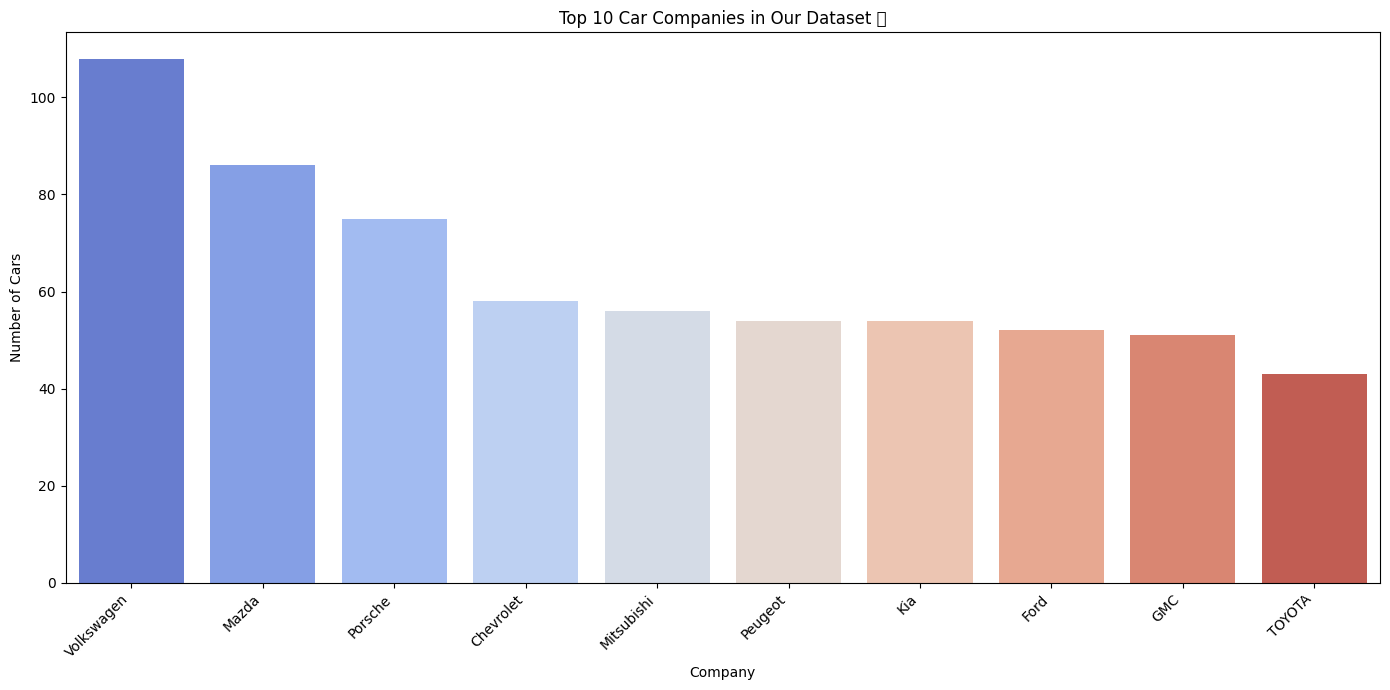

In [ ]:

plt.figure(figsize=(14, 7))
company_counts = df['company_names'].value_counts().head(10)
sns.barplot(x=company_counts.index, y=company_counts.values, palette='coolwarm')
plt.title('Top 10 Car Companies in Our Dataset 🏭')
plt.xlabel('Company')
plt.ylabel('Number of Cars')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

 We can see which brands are most common, but this doesn't tell us about their value.

/tmp/ipython-input-414846826.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='company_names', y='cars_prices', data=df_top_10, palette='viridis')


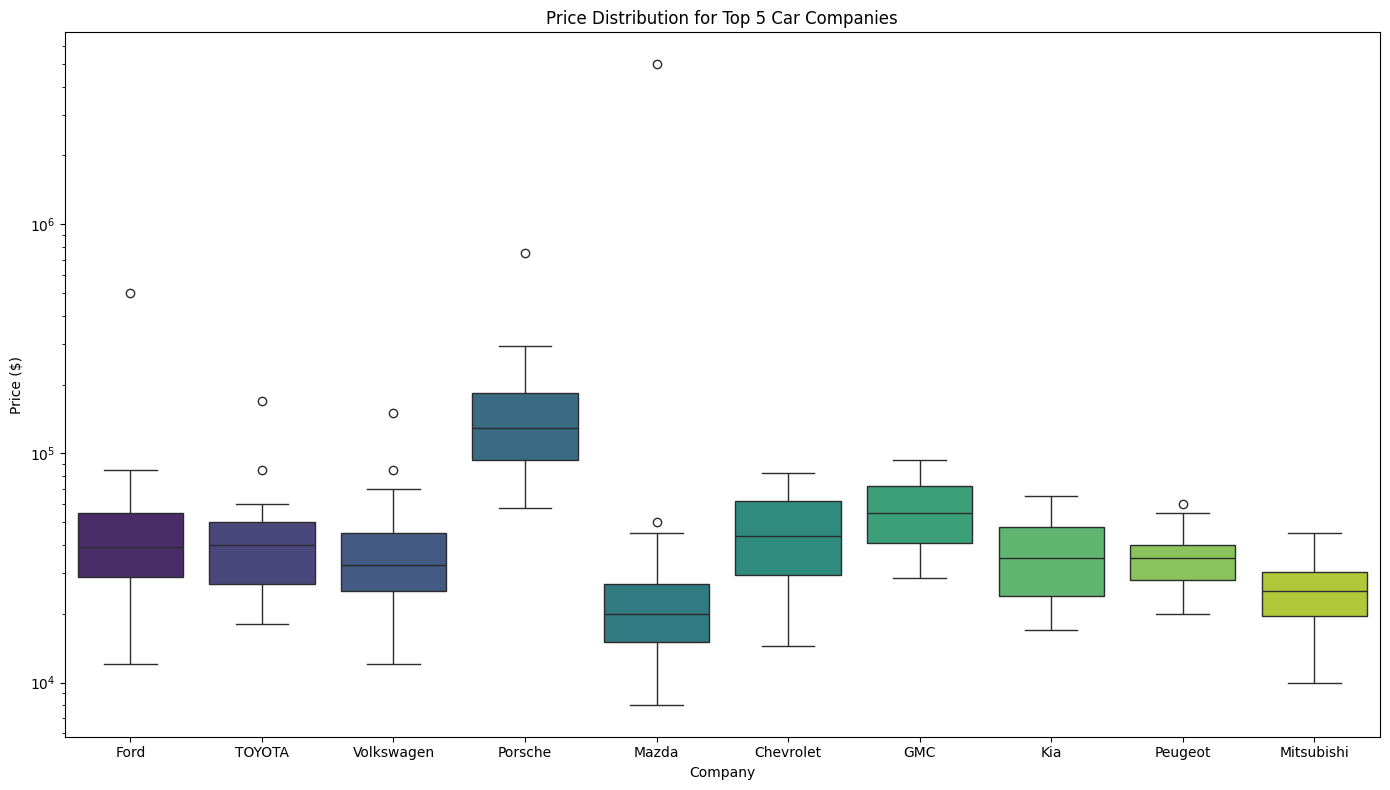

In [ ]:
top_10_companies = df['company_names'].value_counts().head(10).index
df_top_10 = df[df['company_names'].isin(top_10_companies)]

plt.figure(figsize=(14, 8))
sns.boxplot(x='company_names', y='cars_prices', data=df_top_10, palette='viridis')
plt.title('Price Distribution for Top 5 Car Companies')
plt.xlabel('Company')
plt.ylabel('Price ($)')
plt.yscale('log') # We use a log scale to handle the huge price differences.
plt.tight_layout()
plt.show()


 While a company might have many cars, its price range can vary wildly. This is a much richer insight than just a bar chart of average price!

 Porsche has the highest average price and also the highest.

/tmp/ipython-input-3857712299.py:7: UserWarning: Glyph 128168 (\N{DASH SYMBOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128168 (\N{DASH SYMBOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


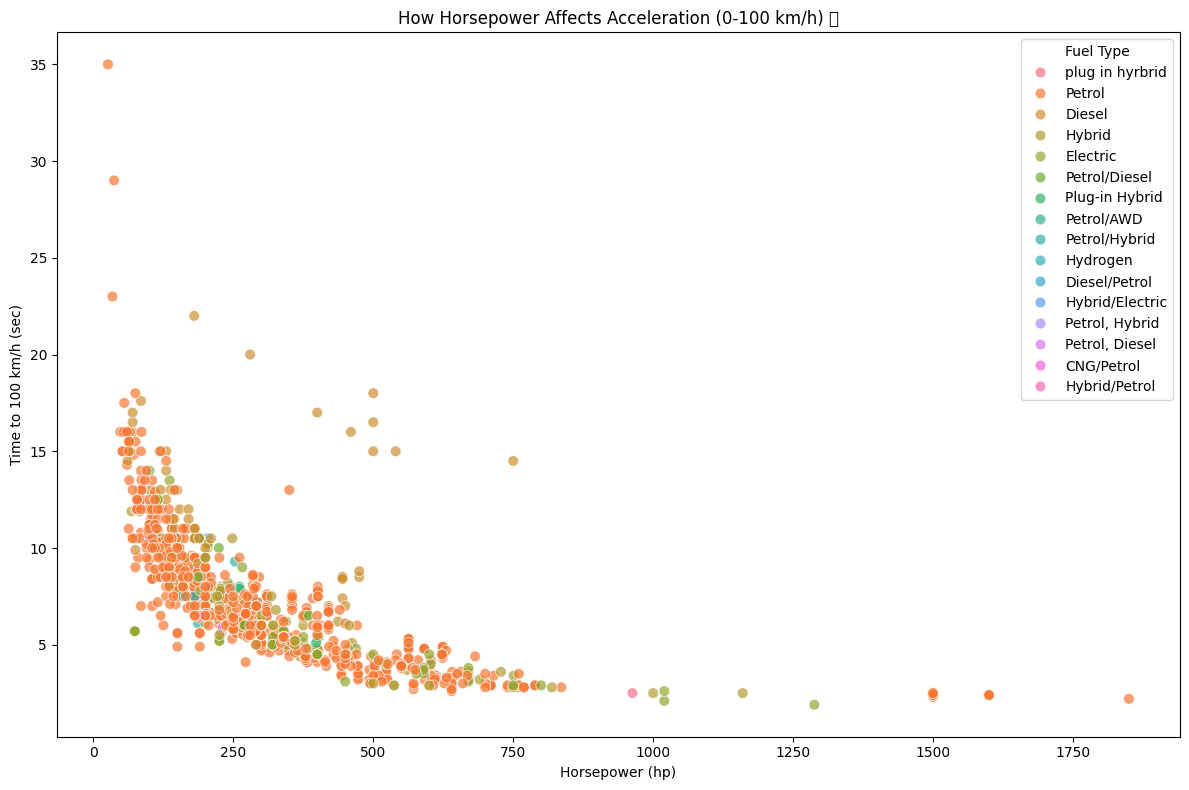

In [ ]:
plt.figure(figsize=(12, 8))
sns.scatterplot(x='horsepower', y='performance_0_100', hue='fuel_types', data=df, s=60, alpha=0.7)
plt.title('How Horsepower Affects Acceleration (0-100 km/h) 💨')
plt.xlabel('Horsepower (hp)')
plt.ylabel('Time to 100 km/h (sec)')
plt.legend(title='Fuel Type')
plt.tight_layout()
plt.show()

This plot clearly shows an inverse relationship: more horsepower means faster acceleration.

Electric cars often have fast acceleration even with lower horsepower due to instant torque.

/tmp/ipython-input-2527827405.py:6: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


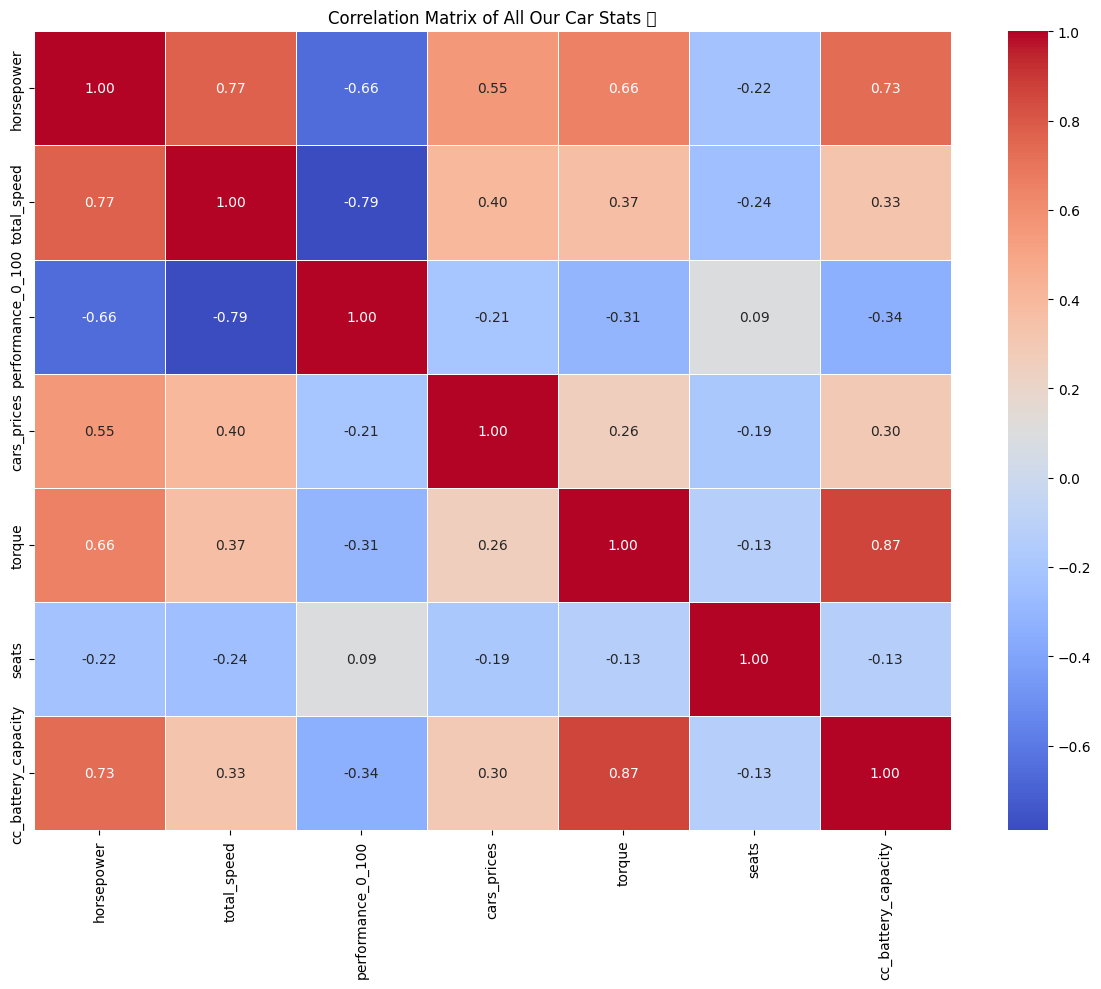

In [ ]:
numeric_df = df[['horsepower', 'total_speed', 'performance_0_100', 'cars_prices', 'torque', 'seats', 'cc_battery_capacity']]
corr_matrix = numeric_df.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of All Our Car Stats 📊')
plt.tight_layout()
plt.show()


Horsepower, total speed, and torque are all strongly linked.

Performance has a strong negative relationship with all of them, meaning more power = less time to accelerate!

/tmp/ipython-input-2193207623.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=fuel_counts.index, y=fuel_counts.values, palette='Set1')


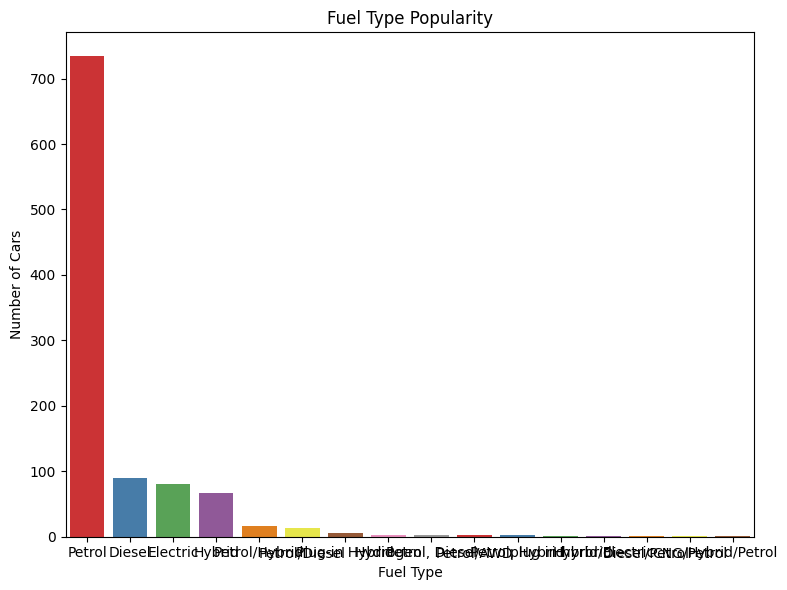

In [ ]:
plt.figure(figsize=(8, 6))
fuel_counts = df['fuel_types'].value_counts()
sns.barplot(x=fuel_counts.index, y=fuel_counts.values, palette='Set1')
plt.title('Fuel Type Popularity')
plt.xlabel('Fuel Type')
plt.ylabel('Number of Cars')
plt.tight_layout()
plt.show()

 Petrol cars dominate the dataset, with Electric and Hybrid cars making up a smaller but significant portion.

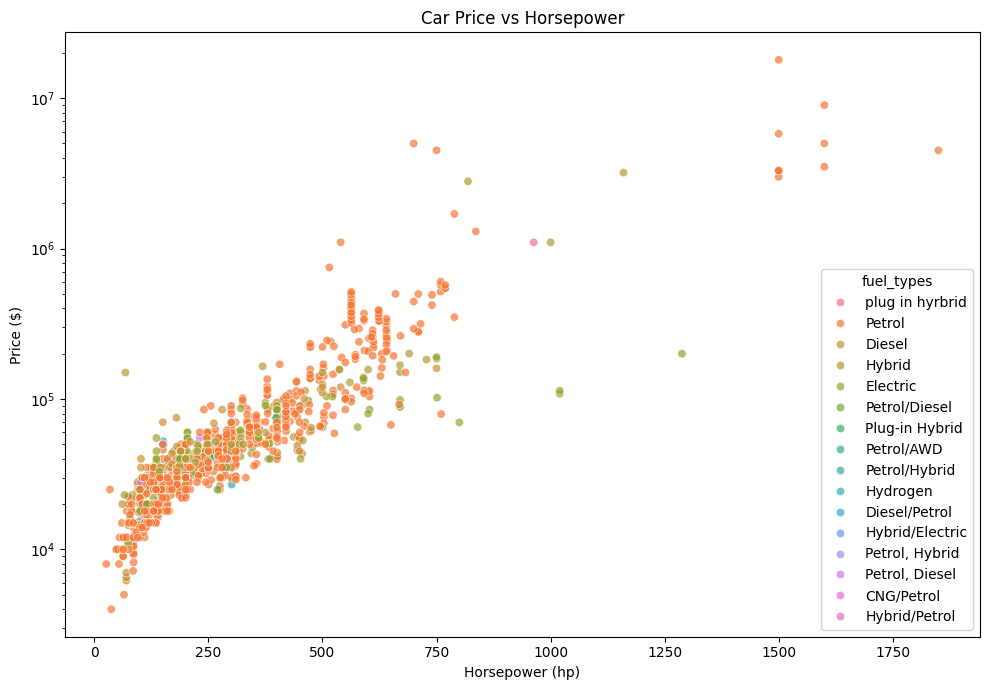

In [ ]:
plt.figure(figsize=(10, 7))
sns.scatterplot(x='horsepower', y='cars_prices', hue='fuel_types', data=df, alpha=0.7)
plt.title('Car Price vs Horsepower')
plt.xlabel('Horsepower (hp)')
plt.ylabel('Price ($)')
plt.yscale('log')
plt.tight_layout()
plt.show()

Higher horsepower cars tend to be more expensive, especially among Petrol and Diesel vehicles. Electric cars show a wide price range even at lower horsepower.
